In [ ]:
from google.colab import files
uploaded=files.upload()

Saving layoffs.csv to layoffs.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
df=pd.read_csv('layoffs.csv')
print(df)

             company            location  total_laid_off        date  \
0            Sapiens  Tel Aviv, Non-U.S.           700.0  12/28/2025   
1          Yellow.ai         SF Bay Area           100.0  12/23/2025   
2     The Trade Desk         Los Angeles             NaN  12/17/2025   
3             Amazon             Seattle            84.0  12/15/2025   
4        PowerSchool          Sacramento             NaN  12-12-2025   
...              ...                 ...             ...         ...   
4248         Service         Los Angeles             NaN   3/16/2020   
4249    HopSkipDrive         Los Angeles             8.0   3/13/2020   
4250     Panda Squad         SF Bay Area             6.0   3/13/2020   
4251   Tamara Mellon         Los Angeles            20.0  03-12-2020   
4252        EasyPost      Salt Lake City            75.0  03-11-2020   

      percentage_laid_off        industry     stage  funds_raised  \
0                    0.15         Finance  Acquired          88.0 

In [ ]:
df.columns

Index(['company', 'location', 'total_laid_off', 'date', 'percentage_laid_off',
       'industry', 'stage', 'funds_raised', 'country', 'date_added'],
      dtype='object')

In [ ]:
df.shape

(4253, 10)

In [ ]:
df.loc[1:3]

,company,location,total_laid_off,date,percentage_laid_off,industry,stage,funds_raised,country,date_added
1,Yellow.ai,SF Bay Area,100.0,12/23/2025,0.3,Support,Series C,102.0,United States,12/26/2025
2,The Trade Desk,Los Angeles,NaN,12/17/2025,NaN,Marketing,Post-IPO,257.0,United States,12/19/2025
3,Amazon,Seattle,84.0,12/15/2025,NaN,Retail,Post-IPO,8100.0,United States,12/19/2025


In [ ]:
df.isnull().sum()

,0
company,0
location,1
total_laid_off,1471
date,0
percentage_laid_off,1564
industry,2
stage,5
funds_raised,482
country,2
date_added,0


In [ ]:
df['total_laid_off']=df['total_laid_off'].fillna(0)

In [ ]:
df.isnull().sum()

,0
company,0
location,1
total_laid_off,0
date,0
percentage_laid_off,1564
industry,2
stage,5
funds_raised,482
country,2
date_added,0


In [ ]:
df['percentage_laid_off']=df['percentage_laid_off'].fillna(df['percentage_laid_off'].mean())

In [ ]:
df.isnull().sum()

,0
company,0
location,1
total_laid_off,0
date,0
percentage_laid_off,0
industry,2
stage,5
funds_raised,482
country,2
date_added,0


In [ ]:
df.describe()

,total_laid_off,percentage_laid_off,funds_raised
count,4253.000000,4253.000000,3771.000000
mean,188.825065,0.294610,829.075231
std,822.229601,0.241764,4563.656047
min,0.000000,0.000000,0.700000
25%,0.000000,0.140000,53.000000
50%,40.000000,0.294610,171.000000
75%,120.000000,0.294610,479.500000
max,22000.000000,1.000000,121900.000000


In [ ]:
# find Out IQR values
Q1 = df["total_laid_off"].quantile(0.25)
Q3= df["total_laid_off"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower_limit:",lower_limit)
print("Upper_limit:",upper_limit)

Lower_limit: -180.0
Upper_limit: 300.0


In [ ]:
def risk_level(x):
  if x < lower_limit:
    return 'Low'
  elif x > upper_limit:
      return 'High'
  else:
    return 'Normal'

df['Risk_level']=df['total_laid_off'].apply(risk_level)

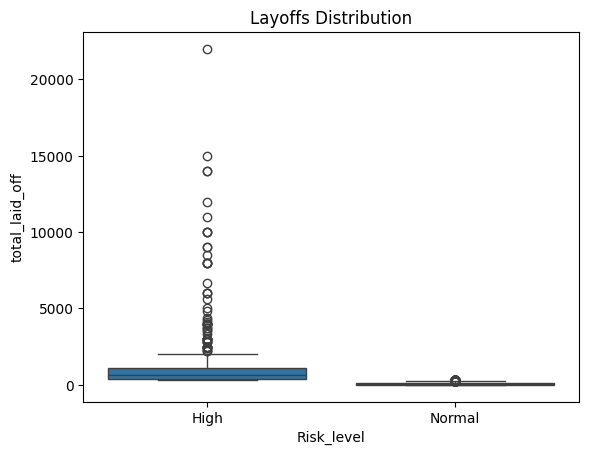

In [ ]:
plt.figure()
sns.boxplot(x='Risk_level',y='total_laid_off', data=df)
plt.title("Layoffs Distribution")
plt.show()

In [ ]:
Q1 = df["total_laid_off"].quantile(0.25)
Q3= df["total_laid_off"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = df[(df["total_laid_off"] < lower_limit)|(df["total_laid_off"] > upper_limit)]
print(len(outliers))

425


In [ ]:
outliers = df[(df["total_laid_off"] < lower_limit)|(df["total_laid_off"] > upper_limit)]
df["total_laid_off"]=df["total_laid_off"].clip(lower=lower_limit,upper=upper_limit)
print(df)

             company            location  total_laid_off        date  \
0            Sapiens  Tel Aviv, Non-U.S.           300.0  12/28/2025   
1          Yellow.ai         SF Bay Area           100.0  12/23/2025   
2     The Trade Desk         Los Angeles             0.0  12/17/2025   
3             Amazon             Seattle            84.0  12/15/2025   
4        PowerSchool          Sacramento             0.0  12-12-2025   
...              ...                 ...             ...         ...   
4248         Service         Los Angeles             0.0   3/16/2020   
4249    HopSkipDrive         Los Angeles             8.0   3/13/2020   
4250     Panda Squad         SF Bay Area             6.0   3/13/2020   
4251   Tamara Mellon         Los Angeles            20.0  03-12-2020   
4252        EasyPost      Salt Lake City            75.0  03-11-2020   

      percentage_laid_off        industry     stage  funds_raised  \
0                 0.15000         Finance  Acquired          88.0 

In [ ]:
Q1 = df["total_laid_off"].quantile(0.25)
Q3= df["total_laid_off"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = df[(df["total_laid_off"] < lower_limit)|(df["total_laid_off"] > upper_limit)]
print(len(outliers))

0


In [ ]:
def risk_level(x):
  if x < lower_limit:
    return 'Low'
  elif x > upper_limit:
      return 'High'
  else:
    return 'Normal'

df['Risk_level']=df['total_laid_off'].apply(risk_level)

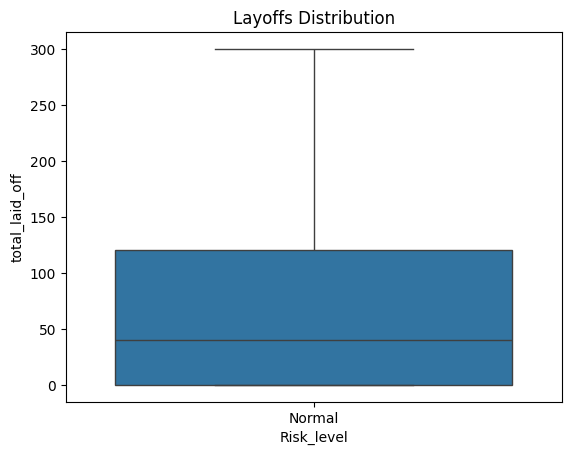

In [ ]:
plt.figure()
sns.boxplot(x='Risk_level',y='total_laid_off', data=df)
plt.title("Layoffs Distribution")
plt.show()

In [ ]:
df.describe()

,total_laid_off,percentage_laid_off,funds_raised
count,4253.000000,4253.000000,3771.000000
mean,80.706325,0.294610,829.075231
std,100.561989,0.241764,4563.656047
min,0.000000,0.000000,0.700000
25%,0.000000,0.140000,53.000000
50%,40.000000,0.294610,171.000000
75%,120.000000,0.294610,479.500000
max,300.000000,1.000000,121900.000000


In [ ]:
df.to_csv('cleanedlayoffs_data.csv', index = False)